# Crop Yield Prediction for Food Security in Africa.

## 1.Business Understanding

### 1.1 Project Overview 

Agriculture plays an important role in providing food and supporting the economy in many African countries. However, many farmers find it difficult to estimate how much crop they will harvest before planting, and this can in turn lead to poor planning, low productivity, and financial losses.

The aim of this project is to build a machine learning system that predicts crop yield using soil information such as pH, nitrogen, phosphorus, potassium, soil moisture, and field size. This will help farmers make better farming decisions and improve food security.

### 1.2 Stakeholders.
##### The key statekeholders for this project are:
* Farmers and Farmer groups.
* Government Institutions.
* NGOs and development partners.
* Farm inputs providers and suppliers.
* Market Actors.
* Research Institutions and Academia.
* Food Security and Warning bodies.
* Financial Institutions & insurers.
* Consumers.

### 1.3 Business Problem
Food insecurity remains a major challenge in many African countries. Farmers often make planting decisions without knowing how much they are likely to harvest. This can lead to poor planning, inefficient use of fertilizers and other resources, and lower crop production. As a result, farmers may experience financial losses, while governments and agricultural organizations find it difficult to plan for future food needs. Thus creating a need for a a reliable system that can help predict crop yield before planting using soil data.

### 1.4 Objectives
* Develop a machine learning model that can accurately predict crop yield based on soil health indicators and field characteristics.

* Help farmers make informed farming decisions by predicting the expected yield of their selected crop before planting.

* Provide insights that can support farmers, agricultural organizations, and governments in improving agricultural productivity and food security.

## 2. Data Understanding

### Libraries

In [1]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### 2.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### 2.2 Load Data

In [3]:
# load data
df = pd.read_excel('../data/Editted2.xlsx')
df_copy = df.copy()
df.head()

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
0,coffee (green beans),6400,1.00,5.5,25.9,1.9,2.0,3.8,17.4,605.0,325.0
1,coffee (green beans),2000,0.75,5.6,29.4,2.2,7.0,4.4,18.8,440.0,245.0
2,potato,35000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
3,cabbage,60000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
4,peas,4500,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0


### 2.3 Data Exploration

In [4]:
print(df.columns)

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture', 'Organic Matter Need',
       'Lime Need'],
      dtype='object')


In [5]:
print(df.shape)

(13802, 11)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13802 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13802 non-null  object 
 1   Target Yield         13802 non-null  int64  
 2   Field Size           13802 non-null  float64
 3   pH (water)           13776 non-null  float64
 4   Organic Carbon       13768 non-null  float64
 5   Total Nitrogen       13768 non-null  float64
 6   Phosphorus (M3)      13773 non-null  float64
 7   Potassium (exch.)    13773 non-null  float64
 8   Soil moisture        9655 non-null   float64
 9   Organic Matter Need  13768 non-null  float64
 10  Lime Need            13774 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.2+ MB
None


In [7]:
df_missing = df.isnull().sum()
df_missing

Crop Name                 0
Target Yield              0
Field Size                0
pH (water)               26
Organic Carbon           34
Total Nitrogen           34
Phosphorus (M3)          29
Potassium (exch.)        29
Soil moisture          4147
Organic Matter Need      34
Lime Need                28
dtype: int64

In [8]:
df_null = df.isnull().sum() / len(df) * 100
df_null

Crop Name               0.000000
Target Yield            0.000000
Field Size              0.000000
pH (water)              0.188378
Organic Carbon          0.246341
Total Nitrogen          0.246341
Phosphorus (M3)         0.210114
Potassium (exch.)       0.210114
Soil moisture          30.046370
Organic Matter Need     0.246341
Lime Need               0.202869
dtype: float64

In [9]:
df.describe()

,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
count,1.380200e+04,13802.000000,13776.000000,13768.000000,13768.000000,13773.000000,13773.000000,9655.000000,1.376800e+04,1.377400e+04
mean,2.388100e+04,123.463307,6.361474,25.417940,2.271426,12.879416,6.755718,15.568058,4.133714e+05,2.581598e+04
std,3.808466e+05,7185.915011,0.737447,22.254906,2.214835,14.399338,5.422551,8.045762,2.423067e+07,1.773352e+06
min,1.000000e+00,0.001000,4.490000,0.900000,0.100000,0.300000,0.300000,0.800000,0.000000e+00,0.000000e+00
25%,1.200000e+03,0.500000,5.800000,11.900000,1.100000,4.400000,3.000000,8.300000,3.050000e+02,5.000000e+01
50%,4.500000e+03,1.000000,6.380000,19.900000,1.800000,8.300000,5.100000,15.800000,7.800000e+02,1.550000e+02
75%,2.000000e+04,2.000000,6.890000,31.400000,2.700000,15.700000,9.000000,21.700000,1.630000e+03,3.200000e+02
max,4.111111e+07,589674.000000,8.460000,327.200000,24.900000,236.900000,43.400000,50.700000,2.007840e+09,1.468288e+08


In [10]:
# checking for dulicates

df.duplicated().sum()

6

In [11]:
# checking dulicate rows

dups = df[df.duplicated(keep=False)]
dups

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
4413,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
4434,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
12850,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12851,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12852,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12853,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
13705,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13711,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13736,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0
13737,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0


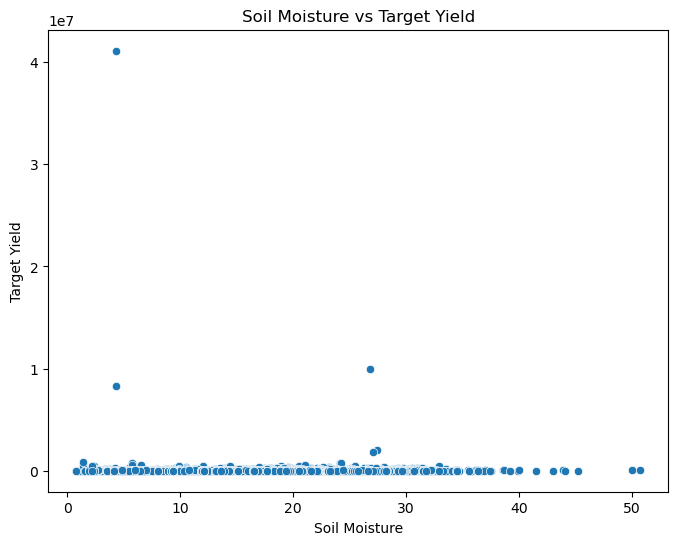

In [12]:
# Check for outliers
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Soil moisture",
    y="Target Yield"
)

plt.title("Soil Moisture vs Target Yield")
plt.xlabel("Soil Moisture")
plt.ylabel("Target Yield")

plt.show()

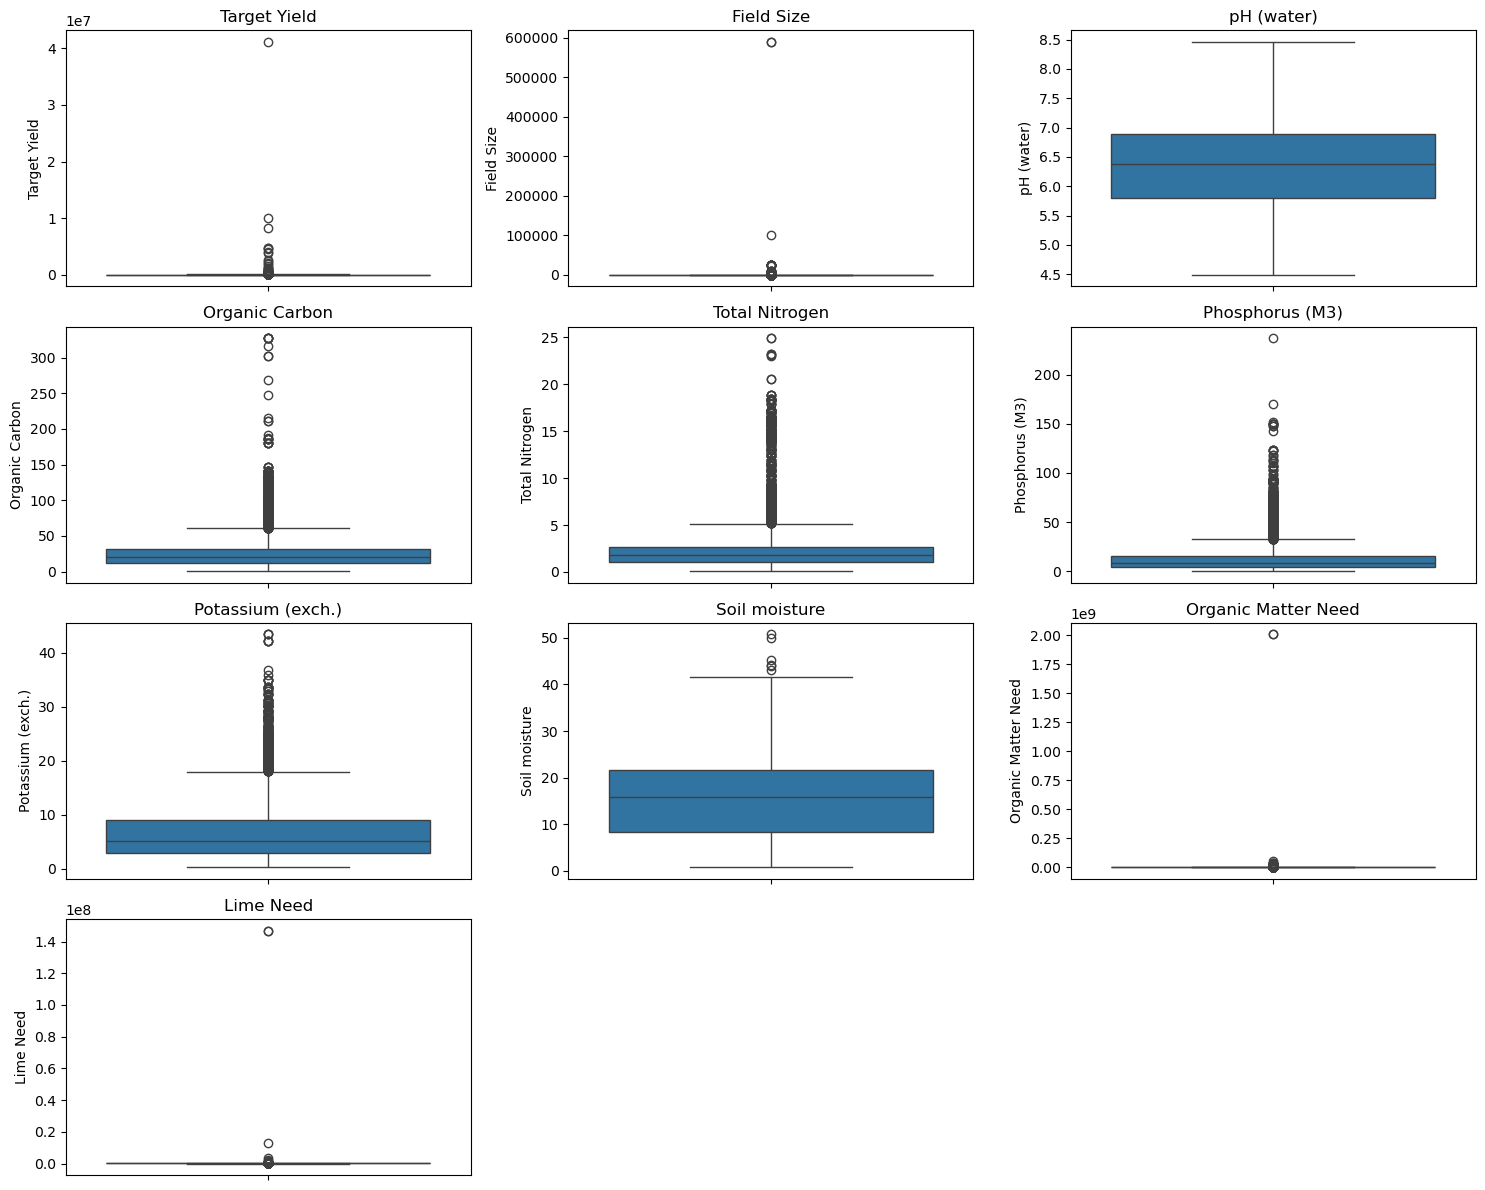

In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##### Identifying Outliers

In [14]:
# Top 20 rows by Target Yield

print(df.nlargest(20, 'Target Yield')[['Crop Name', 'Target Yield', 'Field Size']])

print()

                     Crop Name  Target Yield  Field Size
12192                     oats      41111111     3629.00
971       coffee (green beans)      10000000        8.00
12193                beet root       8333333     3629.00
7832             passion fruit       4800000      160.00
7834                    papaya       4800000      160.00
7789                field bean       4500000        2.50
7823                   cabbage       4000000      160.00
7824                    orange       3840000      160.00
7833                     onion       2560000      160.00
7825                  chillies       2400000      160.00
275       coffee (green beans)       2000000        0.25
296       coffee (green beans)       1850000        2.50
7796                     melon       1500000        0.25
9250   tree tomato (tamarillo)       1250000        7.00
7690             passion fruit       1200000        1.00
7795                    orange       1200000        0.25
13792                    vetch 

In [15]:
# Top 20 rows by Field Size

print(df.nlargest(20, 'Field Size')[['Crop Name', 'Target Yield', 'Field Size']])

            Crop Name  Target Yield  Field Size
12183         soybean          1542    589674.0
12184          grapes         13200    589674.0
12489         avocado        100000    100000.0
10151       sugarcane         80000     23950.0
10152       sugarcane         80000     23950.0
10153       sugarcane         80000     23950.0
10155       sugarcane         80000     23950.0
10163       sugarcane         80000     23950.0
10188       sugarcane         80000     23950.0
10192       sugarcane         80000     23950.0
10197       sugarcane         80000     23950.0
10203       sugarcane         80000     23950.0
10206       sugarcane         80000     23950.0
10207       sugarcane         80000     23950.0
12191     melon-water          8669     21133.0
943           cabbage         10000     10000.0
12188  linseed (flax)        555555      8655.0
12189       butternut         59999      8655.0
12190         tobacco          5653      8655.0
12195          stevia          6134     

In [16]:
# Here we will identify outliers using the IQR method

# Calculate IQR for Target Yield
yield_q1 = df["Target Yield"].quantile(0.25)
yield_q3 = df["Target Yield"].quantile(0.75)
yield_iqr = yield_q3 - yield_q1

yield_lower = yield_q1 - 1.5 * yield_iqr
yield_upper = yield_q3 + 1.5 * yield_iqr

# Calculate IQR for Field Size
field_q1 = df["Field Size"].quantile(0.25)
field_q3 = df["Field Size"].quantile(0.75)
field_iqr = field_q3 - field_q1

field_lower = field_q1 - 1.5 * field_iqr
field_upper = field_q3 + 1.5 * field_iqr

# Identify rows that are outliers in either Target Yield or Field Size
outlier_mask = (
    (df["Target Yield"] < yield_lower) |
    (df["Target Yield"] > yield_upper) |
    (df["Field Size"] < field_lower) |
    (df["Field Size"] > field_upper)
)

# Display outlier information before removing them
print("Rows to remove:", outlier_mask.sum())
print("Rows remaining:", len(df) - outlier_mask.sum())
print("Percentage removed:", round(outlier_mask.sum() / len(df) * 100, 2), "%")

Rows to remove: 1863
Rows remaining: 11939
Percentage removed: 13.5 %


**Data quality issues**

- Extreme outliers: Target Yield maxes at 41,111,111 while the 99th percentile is only 200,000 — almost certainly a handful of data-entry errors or unit mismatches, not real values. Same story for Field Size (max ~589,674 vs. 99th percentile ~15). These need manual inspection — I'd pull the top 10–20 rows by each and decide whether to fix, cap, or drop them.

- Soil moisture is missing in ~30% of rows (4,147/13,802) — needs an imputation strategy or explicit handling.



### 2.3 Data Cleaning

#### a) Dropping duplicates

In [17]:
# drop duplicates
df = df.drop_duplicates()
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13797    False
13798    False
13799    False
13800    False
13801    False
Length: 13796, dtype: bool

##### b) Handling Misssing values in Soil Moisture column

In order to determine the best way to handle the missing values, three options were considered as follows;

    Option 1: K- nearest neighbors

    Option 2: Random forest

    Option 3: XGBoost
    

Thereafter, we computed MAE, RMSE and R-squared for each of the three options then the model with the highest R-Squared and the least MAE and RMSE was selected

##### Option 1: KNN 

In [18]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
#Step 1: Select the variables
cols = [
    "Target Yield",
    "Field Size",
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need",
    "Soil moisture"
]
#Step 2: Keep only complete cases
complete = df[cols].dropna().copy()
#Step 3: Randomly mask 20% of Soil moisture
np.random.seed(42)

mask = np.random.rand(len(complete)) < 0.20

original_values = complete.loc[mask, "Soil moisture"].copy()

complete.loc[mask, "Soil moisture"] = np.nan
#Step 4: Apply KNN Imputation
scaler = StandardScaler()

scaled = scaler.fit_transform(complete)

imputer = KNNImputer(n_neighbors=5)

imputed = imputer.fit_transform(scaled)

imputed = scaler.inverse_transform(imputed)

imputed_df = pd.DataFrame(imputed, columns=cols)
#Step 5: Evaluate the imputation
predicted = imputed_df.loc[mask, "Soil moisture"]

mse = mean_squared_error(original_values, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(original_values, predicted)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 28.155463424518743
Root Mean Squared Error (RMSE): 5.306172200797741
R² Score: 0.5596402428458274


##### Option 2: Random Forest model

In [19]:
from sklearn.ensemble import RandomForestRegressor

# Start from original data
df_rf = df.copy()

predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

# Split rows
known = df_rf[
    df_rf['Soil moisture'].notna()
]

missing = df_rf[
    df_rf['Soil moisture'].isna()
]

# Training rows must have complete predictors
train = known[
    predictors + ['Soil moisture']
].dropna()

fillable = missing[
    predictors
].dropna()

print("Training rows:", len(train))
print("Rows to predict:", len(fillable))

# Train Random Forest regressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    train[predictors],
    train['Soil moisture']
)

# Predict missing values
pred = rf.predict(
    fillable[predictors]
)

# Fill values
df_rf.loc[
    fillable.index,
    'Soil moisture'
] = pred

# Remaining missing → median
df_rf['Soil moisture'] = (
    df_rf['Soil moisture']
    .fillna(
        df_rf['Soil moisture'].median()
    )
)

# Summary
print(
    df_rf['Soil moisture']
    .describe()
)

Training rows: 9649
Rows to predict: 4113
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [20]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

train_pred = rf.predict(
    train[predictors]
)

mae = mean_absolute_error(
    train['Soil moisture'],
    train_pred
)

mse = mean_squared_error(
    train['Soil moisture'],
    train_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    train['Soil moisture'],
    train_pred
)

print("R² Score :", round(r2,3))
print("MAE      :", round(mae,3))
print("MSE      :", round(mse,3))
print("RMSE     :", round(rmse,3))

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633


#### Option 3: XGboost

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import numpy as np

# Data for evaluation
predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

known = df[
    predictors + ['Soil moisture']
].dropna()

X = known[predictors]
y = known['Soil moisture']

# Holdout validation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predict
pred = xgb.predict(X_test)

# Metrics
mae = mean_absolute_error(
    y_test,
    pred
)

mse = mean_squared_error(
    y_test,
    pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

MAE : 3.634
MSE : 24.147
RMSE: 4.914
R²  : 0.627


**Conclusion**

Based on the model outputs above, the Random Forest model was selected as the best to predict and impute the missing values for the "Soil Moisture" feature as it was the best performing model overall with the folowing metrics:

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633

Filling missing values with median


In [22]:
cols_to_impute = [
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need"
]

# Impute using the median within each crop
df[cols_to_impute] = (
    df.groupby("Crop Name")[cols_to_impute]
      .transform(lambda x: x.fillna(x.median()))
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.8+ MB


Fill the null values in Soil Moisture column

In [24]:
df['Soil moisture'] = known['Soil moisture']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.8+ MB


In [25]:
# Replace the Soil moisture column in the original dataframe
df['Soil moisture'] = df_rf['Soil moisture']

# Check that there are no missing values
print(df['Soil moisture'].isna().sum())

# Summary
print(df['Soil moisture'].describe())

0
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        13796 non-null  float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.8+ MB


##### c) Handling Outliers

#### Since different crops naturally have different yield ranges and field sizes, we  check outliers per crop. For example, Maize may naturally produce much higher yields than beans.

In [27]:
# Create empty mask
outlier_mask = pd.Series(False, index=df.index)

# List to store summary for each crop
summary = []

# Loop through each crop
for crop in df["Crop Name"].unique():

    crop_df = df[df["Crop Name"] == crop]

    # ---------------- Target Yield ----------------
    yield_q1 = crop_df["Target Yield"].quantile(0.25)
    yield_q3 = crop_df["Target Yield"].quantile(0.75)
    yield_iqr = yield_q3 - yield_q1

    yield_lower = yield_q1 - 1.5 * yield_iqr
    yield_upper = yield_q3 + 1.5 * yield_iqr

    yield_outliers = (
        (crop_df["Target Yield"] < yield_lower) |
        (crop_df["Target Yield"] > yield_upper)
    )

    # ---------------- Field Size ----------------
    field_q1 = crop_df["Field Size"].quantile(0.25)
    field_q3 = crop_df["Field Size"].quantile(0.75)
    field_iqr = field_q3 - field_q1

    field_lower = field_q1 - 1.5 * field_iqr
    field_upper = field_q3 + 1.5 * field_iqr

    field_outliers = (
        (crop_df["Field Size"] < field_lower) |
        (crop_df["Field Size"] > field_upper)
    )

    # Rows to remove (outlier in either column)
    crop_outliers = yield_outliers | field_outliers

    outlier_mask.loc[crop_df.index] = crop_outliers

    # Store statistics
    summary.append({
        "Crop Name": crop,
        "Yield Outliers": yield_outliers.sum(),
        "Field Size Outliers": field_outliers.sum(),
        "Rows to Remove": crop_outliers.sum(),
        "Rows Remaining": len(crop_df) - crop_outliers.sum(),
        "% Removed": round(crop_outliers.sum() / len(crop_df) * 100, 2)
    })

# Convert to DataFrame
outlier_summary = pd.DataFrame(summary)

# Display
outlier_summary.sort_values("Rows to Remove", ascending=False)

,Crop Name,Yield Outliers,Field Size Outliers,Rows to Remove,Rows Remaining,% Removed
13,maize (corn),150,408,487,1777,21.51
0,coffee (green beans),134,198,290,1289,18.37
9,maize-beans intercrop,47,149,163,668,19.61
4,field bean,57,60,89,385,18.78
19,avocado,49,28,77,398,16.21
...,...,...,...,...,...,...
25,arabica juvenile,0,0,0,2,0.00
77,mature oil palm,0,0,0,3,0.00
79,immature oil palm,0,0,0,1,0.00
80,vetch,0,0,0,2,0.00


In [28]:
print("Overall Rows to Remove:", outlier_mask.sum())
print("Overall Rows Remaining:", len(df) - outlier_mask.sum())
print("Overall Percentage Removed:",
      round(outlier_mask.sum() / len(df) * 100, 2), "%")

Overall Rows to Remove: 2013
Overall Rows Remaining: 11783
Overall Percentage Removed: 14.59 %


In [29]:
# Remove the outliers
df = df[~outlier_mask].reset_index(drop=True)

# Display the new shape of the dataset
print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (11783, 11)


#### d) Dropping the unnecessary columns
We remove this columns because they are not available before crop yield prediction. Since the goal of this project is to predict crop yield using the farmer's soil information, these columns would not be useful during prediction and could introduce data leakage.


In [30]:
# drop the columns we dont need
#list of columns we want to drop
drop_columns= [
    "Organic Matter Need",
    "Lime Need"
]

df.drop(columns=drop_columns, inplace=True)

df.columns

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture'],
      dtype='object')

In [31]:
placeholders = ["NA", "N/A", "NULL", "null", "?", "", " ", "Unknown"]

for p in placeholders:
    print(f"\nPlaceholder: '{p}'")
    print((df == p).sum())


Placeholder: 'NA'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'N/A'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'NULL'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'null'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: '?'
Crop Name            

### 2.4 Target Variable 

##### The Target variable for this project is "Target Yield". This is what the machine learning model will predict

In [32]:
df["Target Yield"].head()

0     6400
1     2000
2    35000
3    60000
4     4500
Name: Target Yield, dtype: int64

In [33]:
df["Target Yield"].describe()

count     11783.000000
mean      12160.350844
std       21069.924768
min           1.000000
25%        1000.000000
50%        3600.000000
75%       15000.000000
max      863247.000000
Name: Target Yield, dtype: float64

### 2.5 Exploratory Data Analysis

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11783 entries, 0 to 11782
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Crop Name          11783 non-null  object 
 1   Target Yield       11783 non-null  int64  
 2   Field Size         11783 non-null  float64
 3   pH (water)         11783 non-null  float64
 4   Organic Carbon     11783 non-null  float64
 5   Total Nitrogen     11783 non-null  float64
 6   Phosphorus (M3)    11783 non-null  float64
 7   Potassium (exch.)  11783 non-null  float64
 8   Soil moisture      11783 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 828.6+ KB


In [43]:
df.shape

(11783, 9)

- Univariate Analysis (One Variable)

-- Categorical Variable: Crop Name
Frequency Table

In [36]:
df["Crop Name"].value_counts()

Crop Name
maize (corn)             1777
coffee (green beans)     1289
potato                   1252
maize-beans intercrop     668
cabbage                   578
                         ... 
oats                        3
vetch                       2
arabica juvenile            2
immature oil palm           1
nuts                        1
Name: count, Length: 82, dtype: int64

- Percentage Distribution

In [37]:
(df["Crop Name"].value_counts(normalize=True) * 100).round(2)

Crop Name
maize (corn)             15.08
coffee (green beans)     10.94
potato                   10.63
maize-beans intercrop     5.67
cabbage                   4.91
                         ...  
oats                      0.03
vetch                     0.02
arabica juvenile          0.02
immature oil palm         0.01
nuts                      0.01
Name: proportion, Length: 82, dtype: float64

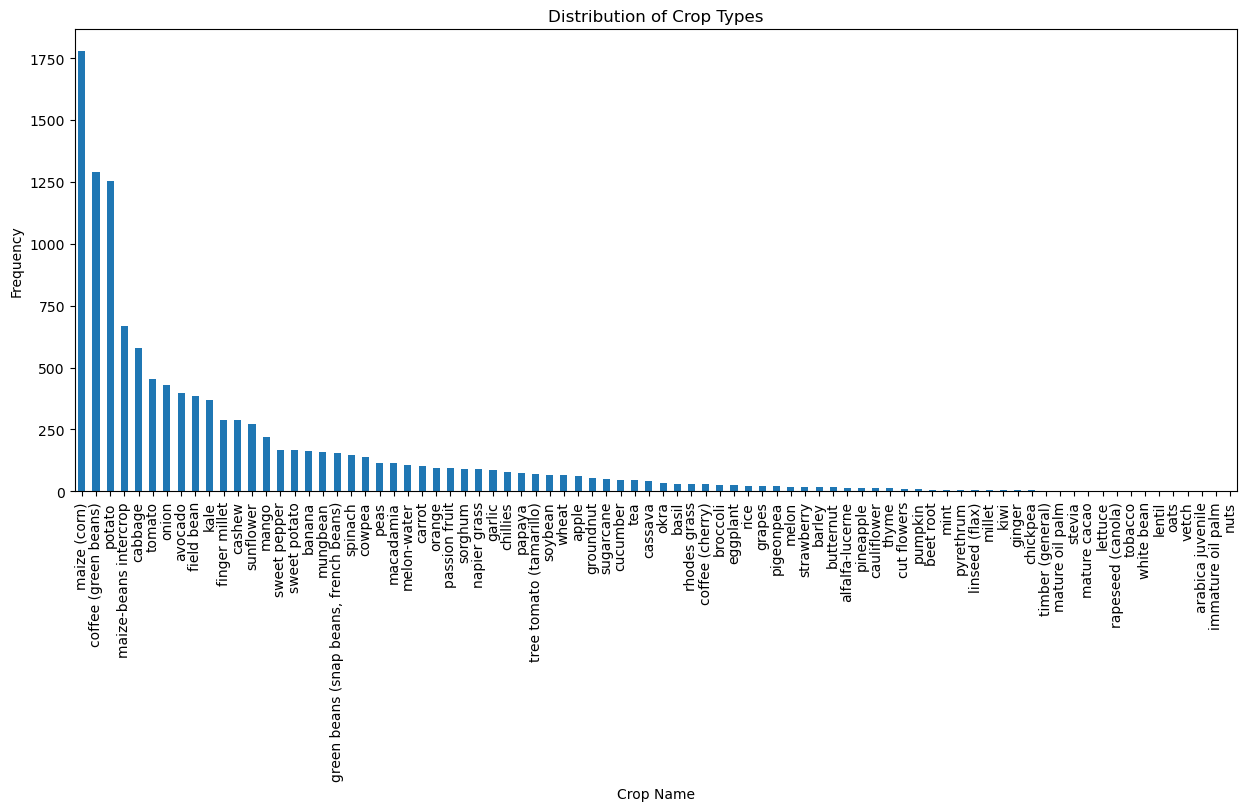

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

df["Crop Name"].value_counts().plot(kind="bar")

plt.ylabel("Frequency")
plt.xlabel("Crop Name")
plt.title("Distribution of Crop Types")

plt.show()

Bivariate Analysis (Two Variables)

In [39]:
df.corr(numeric_only=True)

,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture
Target Yield,1.000000,0.001242,-0.032321,0.049172,0.051322,-0.001137,0.062588,0.096287
Field Size,0.001242,1.000000,0.015317,-0.011742,-0.010866,0.001003,-0.002710,-0.026029
pH (water),-0.032321,0.015317,1.000000,-0.262457,-0.264364,0.264592,0.350176,-0.325011
Organic Carbon,0.049172,-0.011742,-0.262457,1.000000,0.922660,0.266206,0.242610,0.383097
Total Nitrogen,0.051322,-0.010866,-0.264364,0.922660,1.000000,0.223401,0.188811,0.338205
Phosphorus (M3),-0.001137,0.001003,0.264592,0.266206,0.223401,1.000000,0.399645,-0.055662
Potassium (exch.),0.062588,-0.002710,0.350176,0.242610,0.188811,0.399645,1.000000,0.120177
Soil moisture,0.096287,-0.026029,-0.325011,0.383097,0.338205,-0.055662,0.120177,1.000000


Heatmap

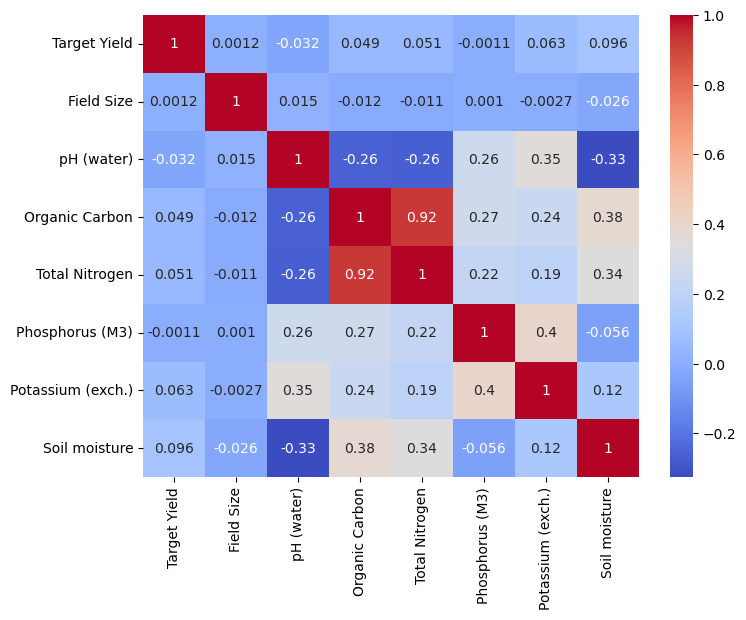

In [40]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Scatterplots

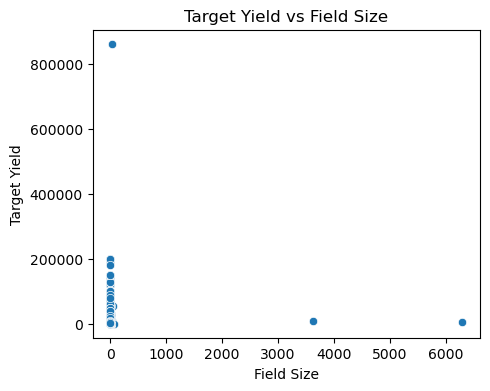

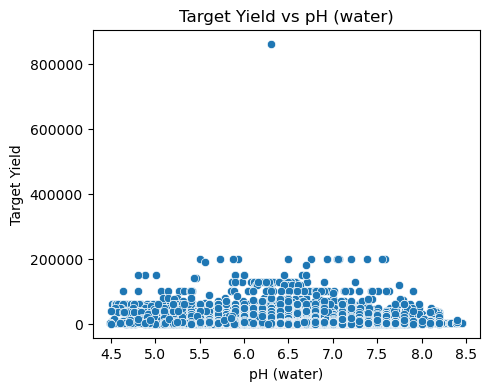

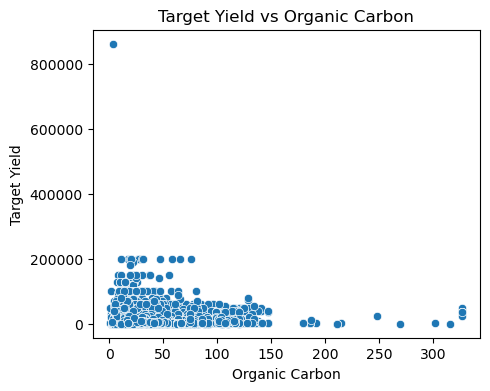

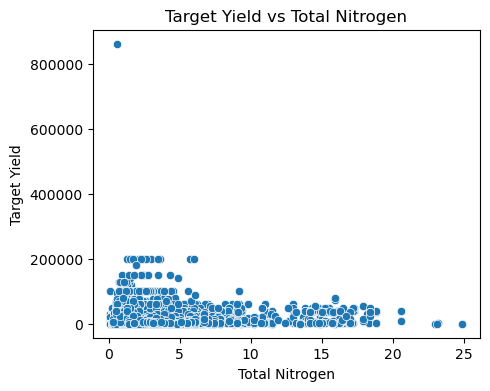

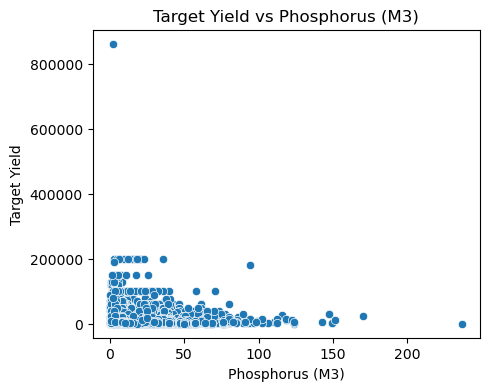

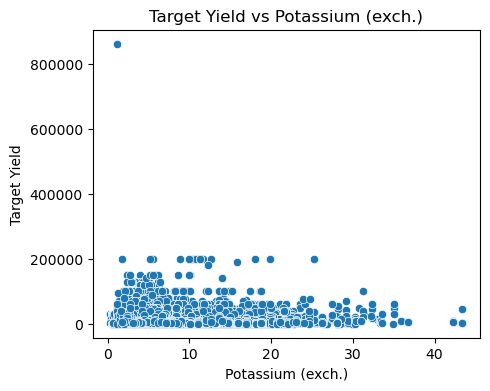

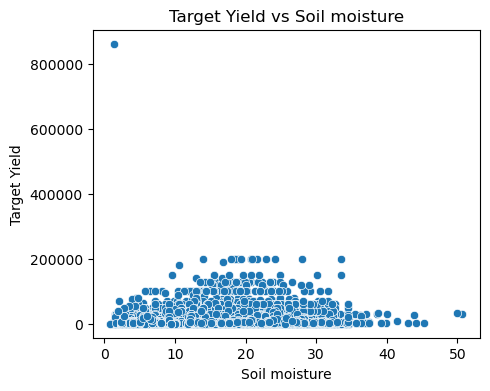

KeyError: 'Organic Matter Need'

<Figure size 500x400 with 0 Axes>

In [41]:
variables = numeric_cols.drop("Target Yield")

for col in variables:

    plt.figure(figsize=(5,4))

    sns.scatterplot(
        x=df[col],
        y=df["Target Yield"]
    )

    plt.title(f"Target Yield vs {col}")

    plt.show()